# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'Artificial intelligence can'
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [8001, 9542, 4430, 460]
  pos 0: id   8001 -> 'Art'
  pos 1: id   9542 -> 'ificial'
  pos 2: id   4430 -> ' intelligence'
  pos 3: id    460 -> ' can'

embedded prompt shape (seq_len, dim): (4, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'Art'        0.343
  'ificial'    0.146
  ' intelligence' 0.437
  ' can'       0.074

logits shape (batch, seq, vocab): (1, 4, 50257)
top 10 next tokens:
  ' be'          0.2086
  ' help'        0.0674
  ' also'        0.0319
  ' make'        0.0255
  ' create'      0.0217
  ' solve'       0.0158
  ' predict'     0.0147
  ' provide'     0.0147
  ' do'          0.0116
  ' take'        0.0115


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

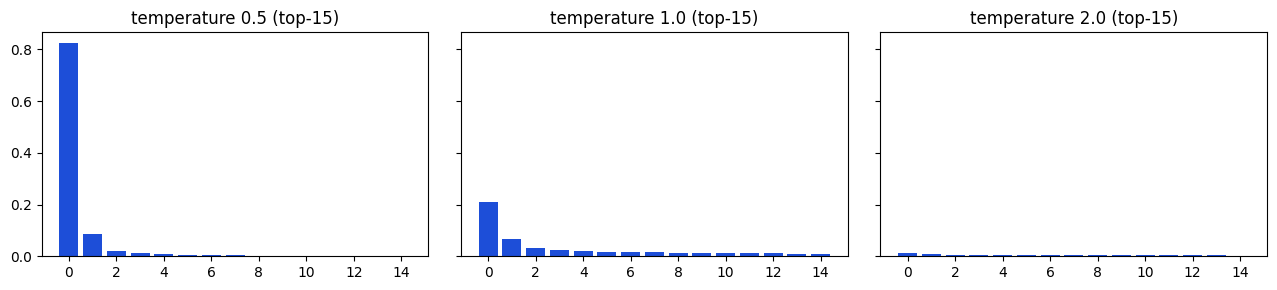

top token prob: temp 0.5 = 0.824, temp 1.0 = 0.209, temp 2.0 = 0.014


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

Tokens before top-k: 50257
Tokens after top-k=10: 10


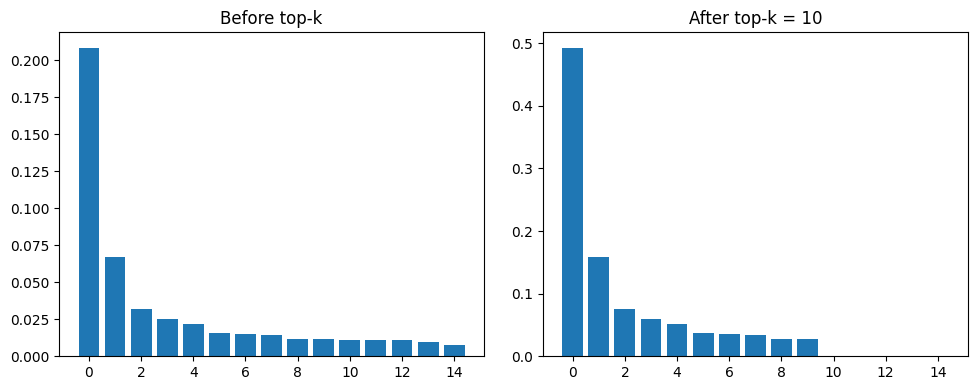

In [4]:
# Top-k filtering: keep only the 10 most likely tokens
base = temperature(z, 1.0)
p_topk = top_k(base, 10)

print("Tokens before top-k:", np.count_nonzero(base))
print("Tokens after top-k=10:", np.count_nonzero(p_topk))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before top-k
axes[0].bar(
    range(15),
    np.sort(base)[::-1][:15]
)
axes[0].set_title("Before top-k")

# After top-k
axes[1].bar(
    range(15),
    np.sort(p_topk)[::-1][:15]
)
axes[1].set_title("After top-k = 10")

plt.tight_layout()
plt.show()

Tokens before top-p: 50257
Tokens after top-p=0.9: 404


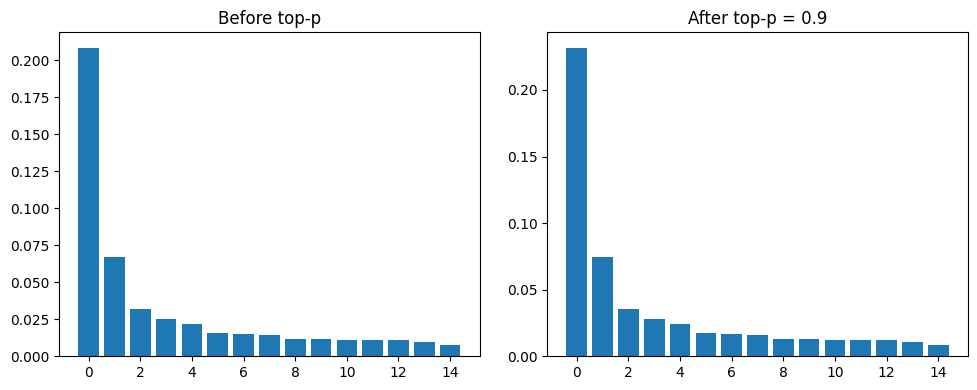

In [5]:
# Top-p filtering: keep tokens until cumulative probability reaches 0.9
base = temperature(z, 1.0)
p_topp, kept = top_p(base, 0.9)

print("Tokens before top-p:", np.count_nonzero(base))
print("Tokens after top-p=0.9:", kept)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(15), np.sort(base)[::-1][:15])
axes[0].set_title("Before top-p")

axes[1].bar(range(15), np.sort(p_topp)[::-1][:15])
axes[1].set_title("After top-p = 0.9")

plt.tight_layout()
plt.show()

Temp 0.7 + top-k 10 keeps: 10 tokens
Temp 1.3 + top-p 0.9 keeps: 1191 tokens


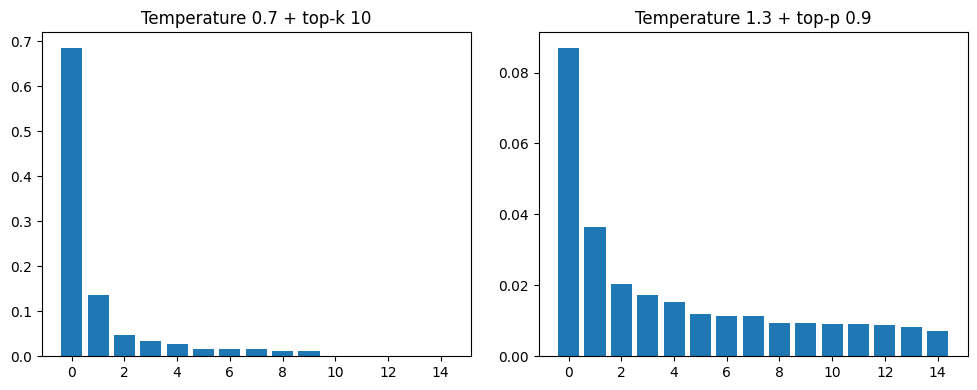

In [6]:
# Combination 1: temperature + top-k
p_temp_topk = top_k(temperature(z, 0.7), 10)

# Combination 2: temperature + top-p
p_temp_topp, kept_topp = top_p(temperature(z, 1.3), 0.9)

print("Temp 0.7 + top-k 10 keeps:", np.count_nonzero(p_temp_topk), "tokens")
print("Temp 1.3 + top-p 0.9 keeps:", kept_topp, "tokens")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(15), np.sort(p_temp_topk)[::-1][:15])
axes[0].set_title("Temperature 0.7 + top-k 10")

axes[1].bar(range(15), np.sort(p_temp_topp)[::-1][:15])
axes[1].set_title("Temperature 1.3 + top-p 0.9")

plt.tight_layout()
plt.show()

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [7]:
def entropy(p):
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


# Setting 1
print("SETTING 1: Temperature = 0.5")
print("Prediction: Lower temperature should introduce less randomness which will cause the model to favor high probability tokens.")
print("So I expect lower entropy, a higher maximum probability, no tokens to be removed.")

p1 = temperature(z, 0.5)

print("Result:")
print("Entropy:", round(entropy(p1), 3))
print("Max probability:", round(p1.max(), 3))
print("Tokens surviving:", np.count_nonzero(p1))


# Setting 2
print("\nSETTING 2: Temperature = 1.0 + top-k = 10")
print("Prediction: Temperature of 1.0 should introduce a bit more randomness while a top-k will reduce the total # of tokens selected to 10")
print("This should concentrate the probability among the 10 tokens.")

p2 = top_k(temperature(z, 1.0), 10)

print("Result:")
print("Entropy:", round(entropy(p2), 3))
print("Max probability:", round(p2.max(), 3))
print("Tokens surviving:", np.count_nonzero(p2))


# Setting 3
print("\nSETTING 3: Temperature = 1.3 + top-p = 0.9")
print("Prediction: A higher temperature should create a more equal distribution across the tokens. ")
print("Additionally, top-p should keep the highest-probability tokens needed to reach 90% of the total probability.")
p3, kept3 = top_p(temperature(z, 1.3), 0.9)

print("Result:")
print("Entropy:", round(entropy(p3), 3))
print("Max probability:", round(p3.max(), 3))
print("Tokens surviving:", kept3)

SETTING 1: Temperature = 0.5
Prediction: Lower temperature should introduce less randomness which will cause the model to favor high probability tokens.
So I expect lower entropy, a higher maximum probability, no tokens to be removed.
Result:
Entropy: 0.883
Max probability: 0.824
Tokens surviving: 50257

SETTING 2: Temperature = 1.0 + top-k = 10
Prediction: Temperature of 1.0 should introduce a bit more randomness while a top-k will reduce the total # of tokens selected to 10
This should concentrate the probability among the 10 tokens.
Result:
Entropy: 1.71
Max probability: 0.493
Tokens surviving: 10

SETTING 3: Temperature = 1.3 + top-p = 0.9
Prediction: A higher temperature should create a more equal distribution across the tokens. 
Additionally, top-p should keep the highest-probability tokens needed to reach 90% of the total probability.
Result:
Entropy: 5.926
Max probability: 0.087
Tokens surviving: 1191


In [8]:
# Results:
# Setting 1 matched my prediction. The low temperature of 0.5 produced a high max
# probability and low entropy. Additionally, all of the original tokens survived because
# no top-k or top-p filtering was applied.

# Setting 2 also matched my prediction. With a temperature of 1.0 and top-k of 10,
# the distribution had slightly higher entropy and a lower max probability than
# setting 1. Top-k also limited the distribution to exactly 10 tokens.

# Setting 3 used a higher temperature of 1.3 and top-p of 0.9. This produced higher
# entropy of nearly 6 and a low maximum probability of 0.087. Top-p kept the
# highest-probability tokens needed to reach 90% of the probability distribution.

# Overall, we can see that a higher temperature increases entropy and reduces the max probability.
# As top-p increases, so does the number of tokens selected. Finally, top-k always selects the k
# tokens with the highest probabilities.

## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [9]:
p = temperature(z, 1.0)

p90, _ = top_p(p, 0.90)
p99, _ = top_p(p, 0.99)
p999, _ = top_p(p, 0.999)
p100, _ = top_p(p, 1.0)

print("top-p = 0.90 keeps:", np.count_nonzero(p90), "tokens")
print("top-p = 0.99 keeps:", np.count_nonzero(p99), "tokens")
print("top-p = 0.999 keeps:", np.count_nonzero(p999), "tokens")
print("top-p = 1.0 keeps:", np.count_nonzero(p100), "tokens")

# Failure/Surprise:
# The surprising result was how quickly the number of selected tokens increased
# as top-p moved closer to 1.0. At top-p = 0.90, only 404 tokens were retained,
# while top-p = 0.99 retained 1,958 tokens, which is almost a five-fold increase.
# Increasing top-p to 0.999 caused another large jump, and top-p = 1.0 retained
# all 50,257 tokens. The jump from 0.999 to 1.0 was especially surprising because
# the threshold changed by only 0.001, but the number of possible tokens increased dramatically.

# Cause:
# The cause is that a large number of tokens have very small probabilities.
# Most of the probability is concentrated in a smaller number of tokens,
# while the remaining probability is divided among many low-probability tokens.
# Therefore, the closer top-p gets to 1.0, the more tokens are included in the sampling pool.

# Mitigation:
# Avoid using top-p values close to 1.0, as the closer you get to 1.0, the greater the likelihood
# that a high number of tokens will be selected. These large numbers of low-probability tokens
# may provide little value to an LLM or application predicting the next token.


top-p = 0.90 keeps: 404 tokens
top-p = 0.99 keeps: 1958 tokens
top-p = 0.999 keeps: 4722 tokens
top-p = 1.0 keeps: 50257 tokens


## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).